In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Global Settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment configured.")

Environment configured.


In [17]:
def load_data(file_path):
    """
    Loads a CSV file into a DataFrame with defensive checks.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Data file not found at: {file_path}")
    
    df = pd.read_csv(file_path)
    print(f"Data loaded successfully. Shape: {df.shape}")
    return df

# Usage
DATA_PATH = "../data/raw/data.csv"
df = load_data(DATA_PATH)

Data loaded successfully. Shape: (95662, 16)


In [18]:
def plot_numerical_distributions(data, columns):
    """
    Plots histograms for a list of numerical columns.
    """
    for col in columns:
        if col not in data.columns:
            print(f"Warning: Column {col} missing from DataFrame.")
            continue
        plt.figure()
        sns.histplot(data[col], bins=50, kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

def plot_boxplots(data, columns):
    """
    Plots boxplots for outlier detection.
    """
    for col in columns:
        plt.figure(figsize=(10, 2))
        sns.boxplot(x=data[col])
        plt.title(f"Outlier Detection: {col}")
        plt.show()

def plot_categorical_counts(data, columns):
    """
    Plots bar charts for categorical columns.
    """
    for col in columns:
        plt.figure()
        data[col].value_counts().plot(kind='bar', color='skyblue')
        plt.title(f"Category Distribution: {col}")
        plt.xticks(rotation=45)
        plt.show()

def plot_correlation(data, columns):
    """
    Plots a correlation heatmap for specific columns.
    """
    corr = data[columns].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Analysis")
    plt.show()

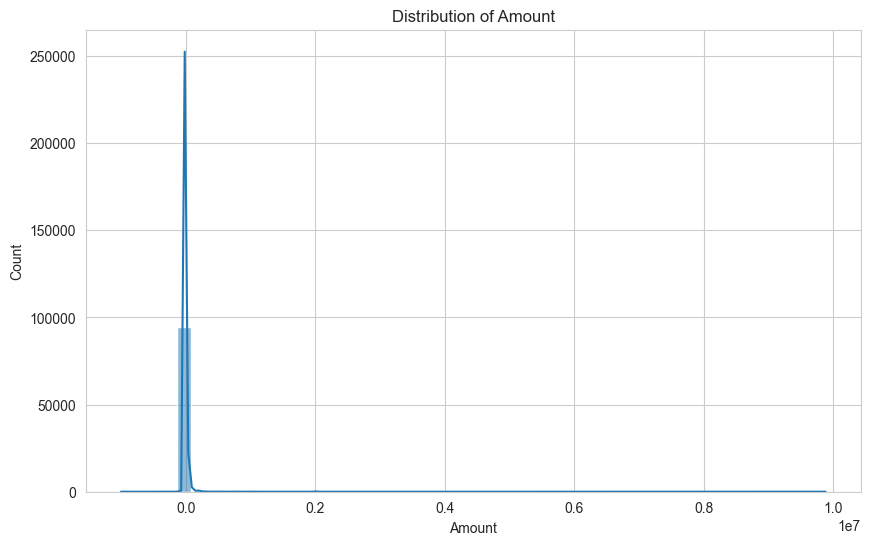

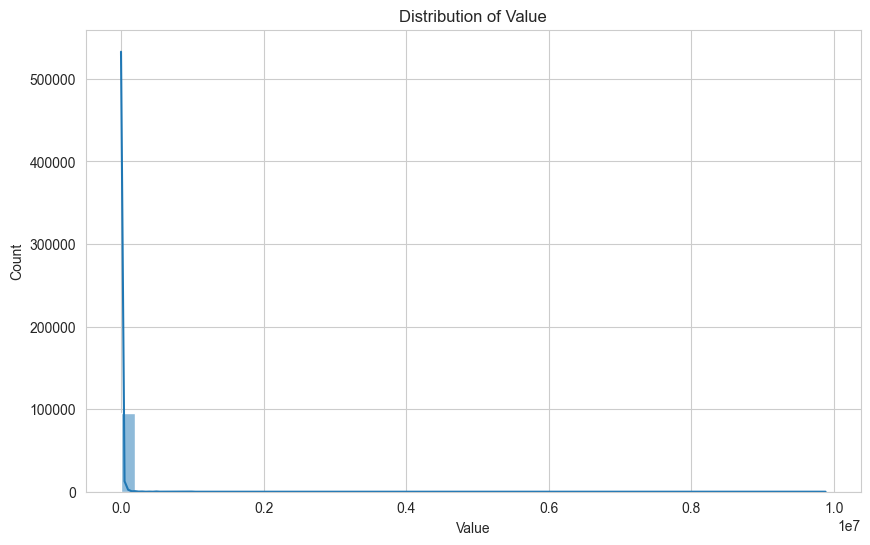

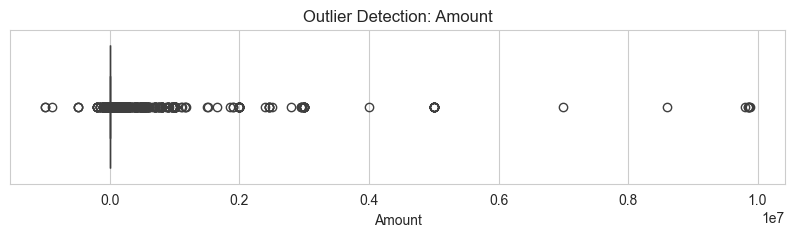

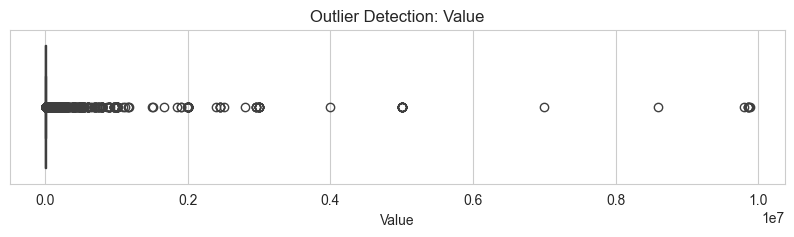

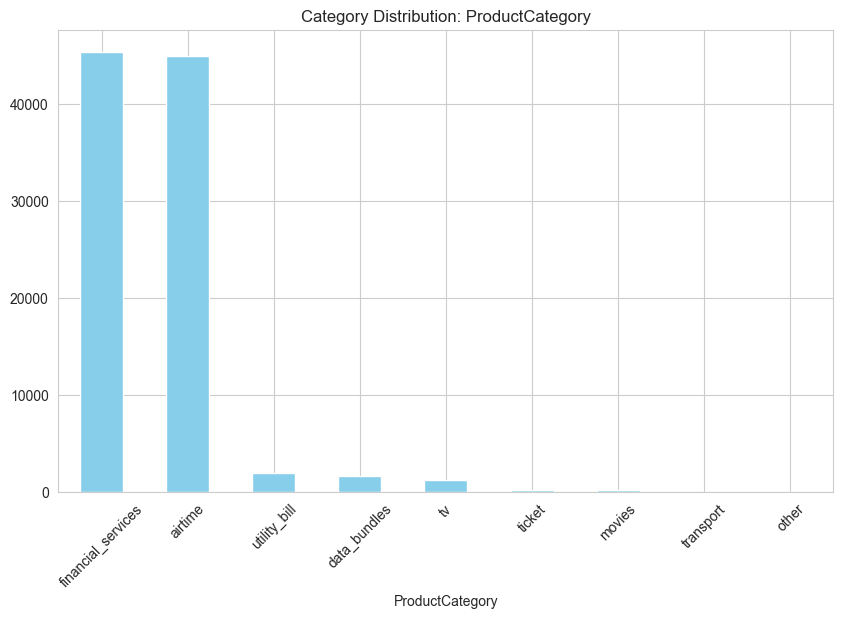

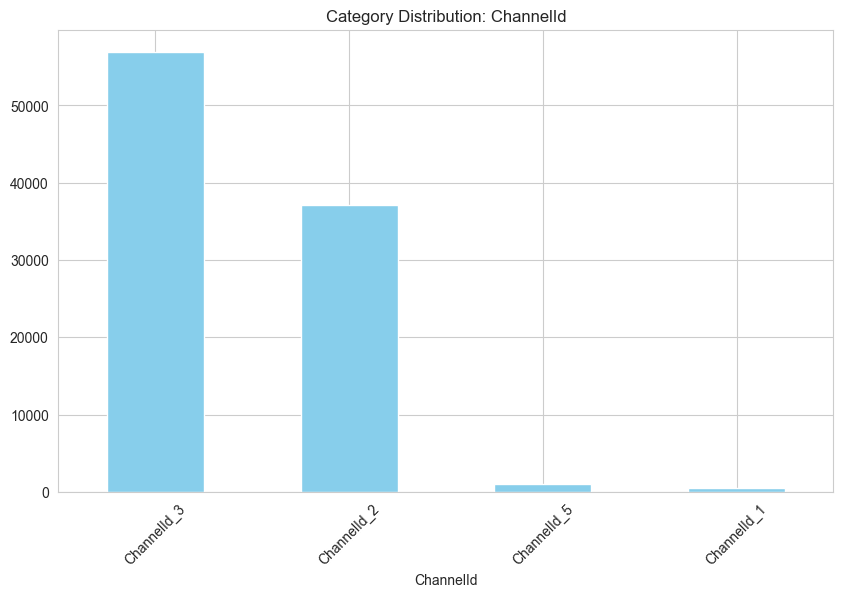

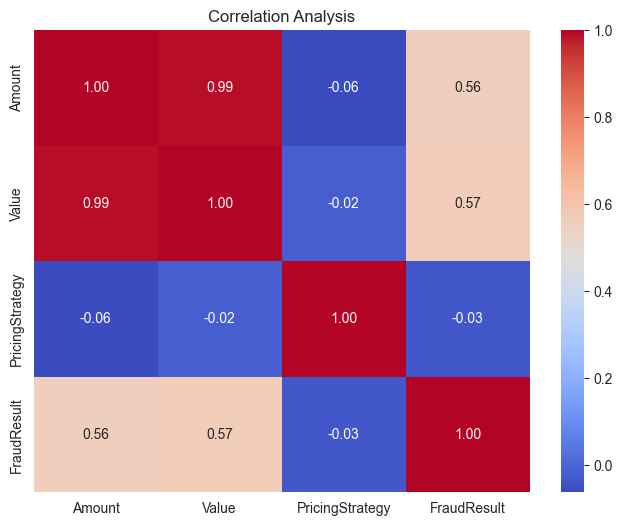

In [19]:
# 1. Numerical Analysis
num_cols = ['Amount', 'Value']
plot_numerical_distributions(df, num_cols)
plot_boxplots(df, num_cols)

# 2. Categorical Analysis
cat_cols = ['ProductCategory', 'ChannelId']
plot_categorical_counts(df, cat_cols)

# 3. Correlation
corr_cols = ['Amount', 'Value', 'PricingStrategy', 'FraudResult']
plot_correlation(df, corr_cols)

In [4]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [5]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

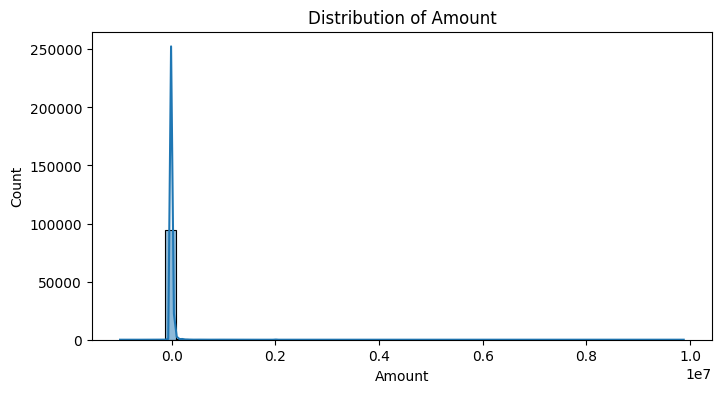

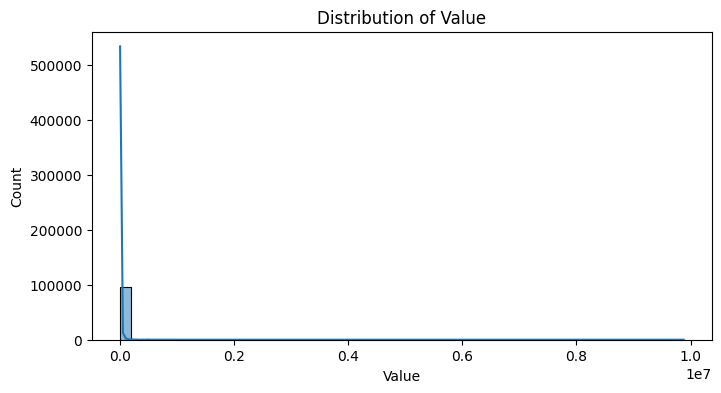

In [6]:
num_cols = ["Amount", "Value"]

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

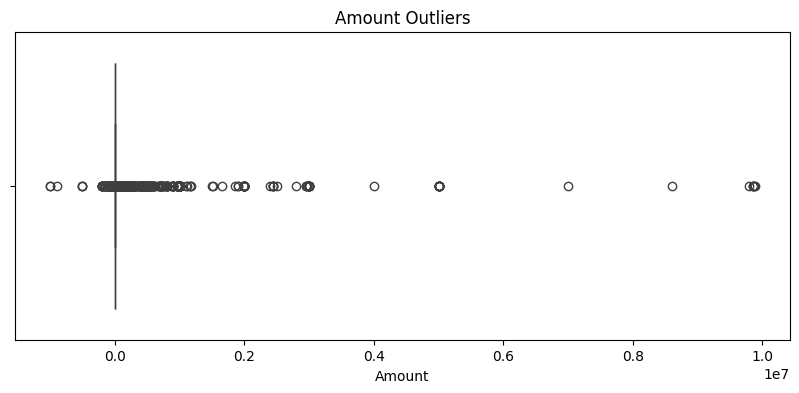

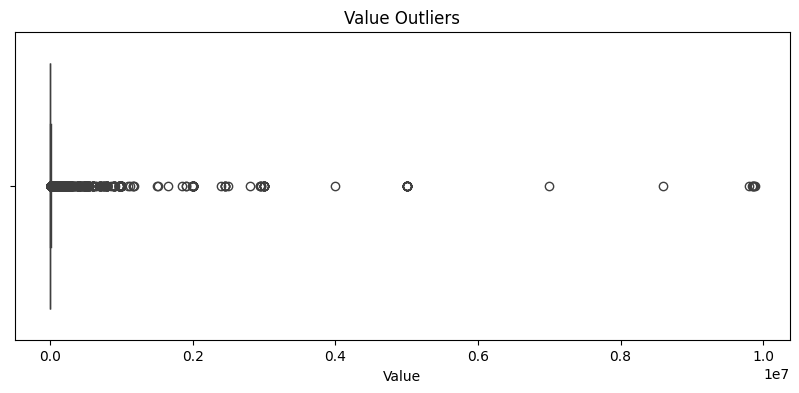

In [7]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df["Amount"])
plt.title("Amount Outliers")
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(x=df["Value"])
plt.title("Value Outliers")
plt.show()

In [8]:
df["ProductCategory"].value_counts()

ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64

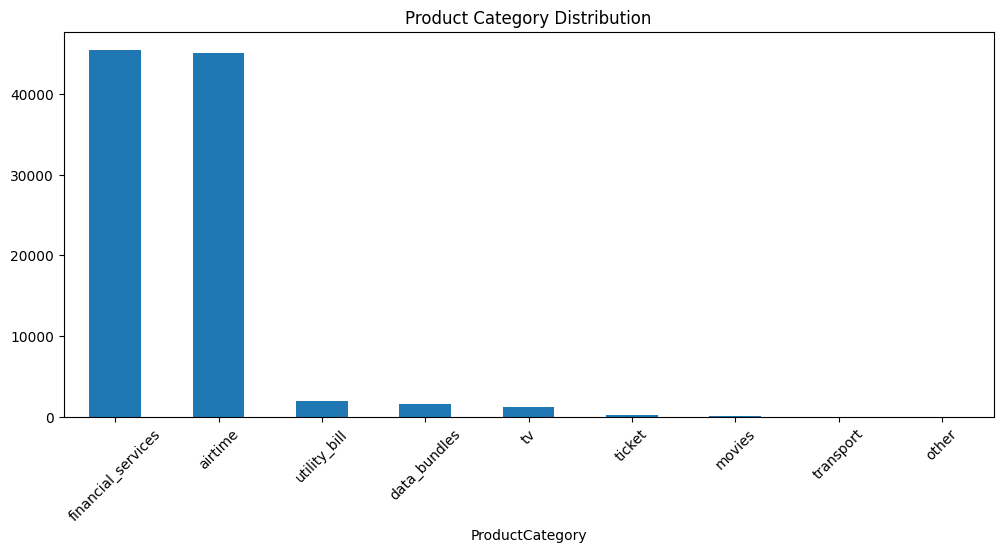

In [9]:
plt.figure(figsize=(12,5))
df["ProductCategory"].value_counts().plot(kind="bar")
plt.title("Product Category Distribution")
plt.xticks(rotation=45)
plt.show()

In [10]:
df["ChannelId"].value_counts()

ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64

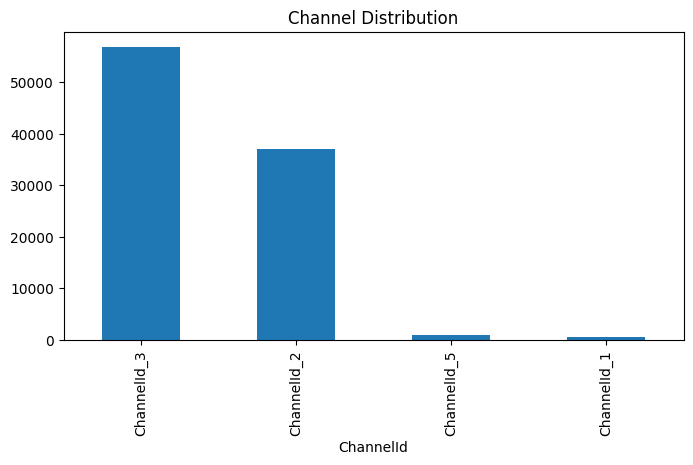

In [11]:
plt.figure(figsize=(8,4))
df["ChannelId"].value_counts().plot(kind="bar")
plt.title("Channel Distribution")
plt.show()

# Summary of Exploratory Data Analysis (EDA)

Based on the analysis performed above, the following key insights have been identified to guide the feature engineering and modeling phases:

1. **High Skewness and Outliers**: Both `Amount` and `Value` distributions are extremely right-skewed with significant outliers reaching up to 10M, while the median transaction is approximately 1,000. This indicates a need for robust scaling (e.g., `StandardScaler` or `RobustScaler`) or log-transformations during feature engineering to ensure model stability.

2. **Categorical Concentration**: Transactions are heavily concentrated in two main categories: `airtime` and `financial_services`. Furthermore, most activity occurs through `ChannelId_3` and `ChannelId_2`. These features will likely be strong predictors for customer behavior segmentation.

3. **Feature Redundancy (Multicollinearity)**: There is a near-perfect correlation (0.99) between `Amount` and `Value`. Since `Value` is essentially the absolute value of `Amount`, including both in a model would introduce multicollinearity. We should prioritize one or derive a new feature (like `TransactionDirection`) to represent the sign.

4. **Severe Class Imbalance**: The `FraudResult` distribution shows that fraudulent transactions are extremely rare (less than 1% of the dataset). When training the risk model, we must use techniques like SMOTE (oversampling), undersampling, or class-weight adjustments to prevent the model from being biased toward the majority class.

5. **Behavioral Patterns for Risk Proxy**: The high frequency of small-value transactions in specific channels suggests that Recency, Frequency, and Monetary (RFM) analysis will be an effective method for engineering the proxy "high-risk" label in Task 4.